# MNIST Digit Recognition with pyTorch

TODO: device

In [1]:
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets
from torchvision.transforms import ToTensor

import utils

In [2]:
import yaml

with open("params.yaml") as f:
    params = yaml.safe_load(f)['mnist']

# frequently used params
width = params['img_width']
height = params['img_height']

utils.print_params(params)

img_width: 28
img_height: 28
random_state: 42
batch_size: 128
learning_rate: 0.001
epochs: 5
ly_fc1_out: 512


In [3]:
# reproducibility
#https://docs.pytorch.org/docs/stable/notes/randomness.html
foo = torch.manual_seed(params['random_state'])

## Dataset

### Load

In [4]:
# TODO: difference between transform=ToTensor() and transform=None ???
train_data = datasets.MNIST(root="./data", train=True, transform=ToTensor(), download=True)
test_data = datasets.MNIST(root="./data", train=False, transform=ToTensor(), download=True)

In [5]:
print(train_data.data.shape, train_data.targets.shape, test_data.data.shape, test_data.targets.shape)
print(set([type(train_data.data), type(train_data.targets), type(test_data.data), type(test_data.targets)]))
print("data.dtype:", set([train_data.data.dtype, test_data.data.dtype]))
print("targets.dtype:", set([train_data.targets.dtype, test_data.targets.dtype]))
print(train_data.data[0].min(), train_data.data[0].max())

torch.Size([60000, 28, 28]) torch.Size([60000]) torch.Size([10000, 28, 28]) torch.Size([10000])
{<class 'torch.Tensor'>}
data.dtype: {torch.uint8}
targets.dtype: {torch.int64}
tensor(0, dtype=torch.uint8) tensor(255, dtype=torch.uint8)


For consistency, `torch.Tensor` -> `np.array`,

In [6]:
train_images = train_data.data\
    .numpy()\
    .reshape((60000, width * height))\
    .astype("float32") / 255
test_images = test_data.data\
    .numpy()\
    .reshape((10000, width * height))\
    .astype("float32") / 255

train_labels = train_data.targets.numpy().astype("uint8")
test_labels = test_data.targets.numpy().astype("uint8")

In [7]:
print(train_images.shape, train_labels.shape, test_images.shape, test_labels.shape)
print(set([type(train_images), type(train_labels), type(test_images), type(test_labels)]))
print("images.dtype:", set([train_images.dtype, test_images.dtype]))
print("labels.dtype:", set([train_labels.dtype, test_labels.dtype]))
print(train_images[0].min(), train_images[0].max())

(60000, 784) (60000,) (10000, 784) (10000,)
{<class 'numpy.ndarray'>}
images.dtype: {dtype('float32')}
labels.dtype: {dtype('uint8')}
0.0 1.0


### Prepare

In [8]:
sorted(set(test_labels))

[np.uint8(0),
 np.uint8(1),
 np.uint8(2),
 np.uint8(3),
 np.uint8(4),
 np.uint8(5),
 np.uint8(6),
 np.uint8(7),
 np.uint8(8),
 np.uint8(9)]

`np.array` -> `torch.Tensor`,

In [9]:
X_train = torch.tensor(train_images, dtype=torch.float32)
X_test = torch.tensor(test_images, dtype=torch.float32)
y_train = torch.tensor(train_labels, dtype=torch.float32).unsqueeze(1)
y_test = torch.tensor(test_labels, dtype=torch.float32).unsqueeze(1)

In [10]:
print(train_images.shape, X_train.shape)
print(train_labels.shape, y_train.shape)

(60000, 784) torch.Size([60000, 784])
(60000,) torch.Size([60000, 1])


In [11]:
print(test_images.shape, X_test.shape)
print(test_labels.shape, y_test.shape)

(10000, 784) torch.Size([10000, 784])
(10000,) torch.Size([10000, 1])


In [12]:
train_dataset = TensorDataset(X_train, y_train)

In [13]:
train_loader = DataLoader(train_dataset, batch_size=params['batch_size'], shuffle=True)

## Model

### Build (architecture)

In [14]:
## simpler way
#model = nn.Sequential(
#    nn.Linear(28 * 28, 512),
#    nn.ReLU(),
#    nn.Linear(512, 10),
#    nn.Softmax(dim=1)
#)

In [15]:
class MNISTNet(nn.Module):  # MNIST network

    def __init__(self):
        super(MNISTNet, self).__init__()

        self.fc1 = nn.Linear(width * height, params['ly_fc1_out'])  # fully connected
        self.fc2 = nn.Linear(params['ly_fc1_out'], 10)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.softmax(self.fc2(x), dim=1)

        return x

In [16]:
model = MNISTNet()

### Compile

In [17]:
optimizer = optim.RMSprop(model.parameters(), lr=params['learning_rate'])
criterion = nn.CrossEntropyLoss()

### Training loop (fit)

In [18]:
# for plotting
losses = []

for epoch in range(params['epochs']):

    model.train()  # training mode
    running_loss = 0.0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()  # reset all gradients

        preds = model(X_batch)

        ## y_batch.shape = [len_batch, 1] i.e., is a tensor([[1.], ... [8.]])
        ## preds.shape = [len_batch, 10]
        loss = criterion(preds, y_batch.squeeze(-1).long())

        loss.backward()  # backpropagation
        optimizer.step()

        running_loss += loss.item()

    av_loss = running_loss / len(train_loader)  # average batch loss
    losses.append(av_loss)
    print(f"Epoch {epoch+1}/{params['epochs']}: Loss was {av_loss}")

Epoch 1/5: Loss was 1.5836533003016067
Epoch 2/5: Loss was 1.5129174850642808
Epoch 3/5: Loss was 1.4990403062499154
Epoch 4/5: Loss was 1.491134707099085
Epoch 5/5: Loss was 1.4855330974054235


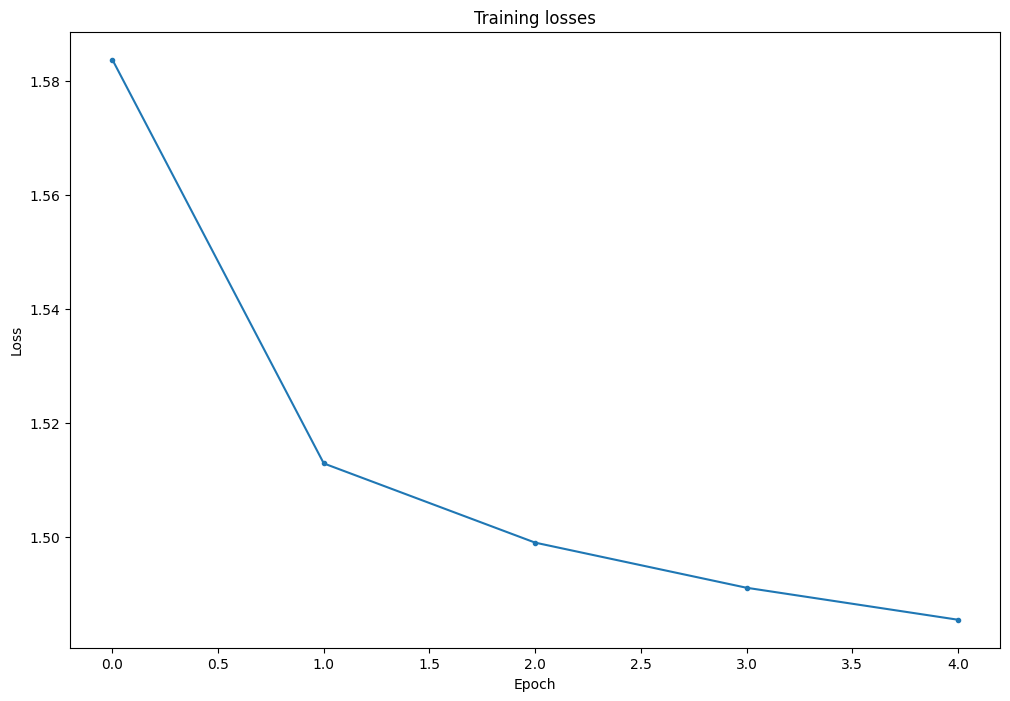

In [19]:
ax = utils.plot_train_losses(params['epochs'], losses)

## Results

### Predictions and Evaluation (accuracy)

In [20]:
with torch.no_grad():
    model.eval()  # evaluation mode

    preds = model(X_test)
    loss = criterion(preds, y_test.squeeze(-1).long()).item()

    equals = model(X_test).argmax(dim=1, keepdim=True) == y_test.long()
    equals = equals.squeeze(-1)

    test_acc = equals.sum().item() / len(equals)

print(f"Test accuracy: {test_acc:.2%}")

Test accuracy: 97.35%


In [21]:
test_images.shape, X_test.shape

((10000, 784), torch.Size([10000, 784]))

In [22]:
notequals = ~equals
notequals = np.where(notequals)[0]
len(notequals)

265

In [23]:
# lists of predicted digits
pred = preds.argmax(dim=1)
real = y_test.squeeze(-1).long()

In [24]:
# check accuracy
print(f"{(len(pred) - len(notequals)) / len(pred):.2%}")

97.35%


### Show

True label + Image:

9.0


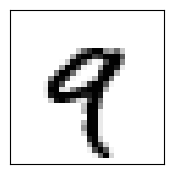

In [25]:
print(y_train[4].item())
utils.imshow(X_train[4].reshape(width, height))

Wrongly labeled digits in test:

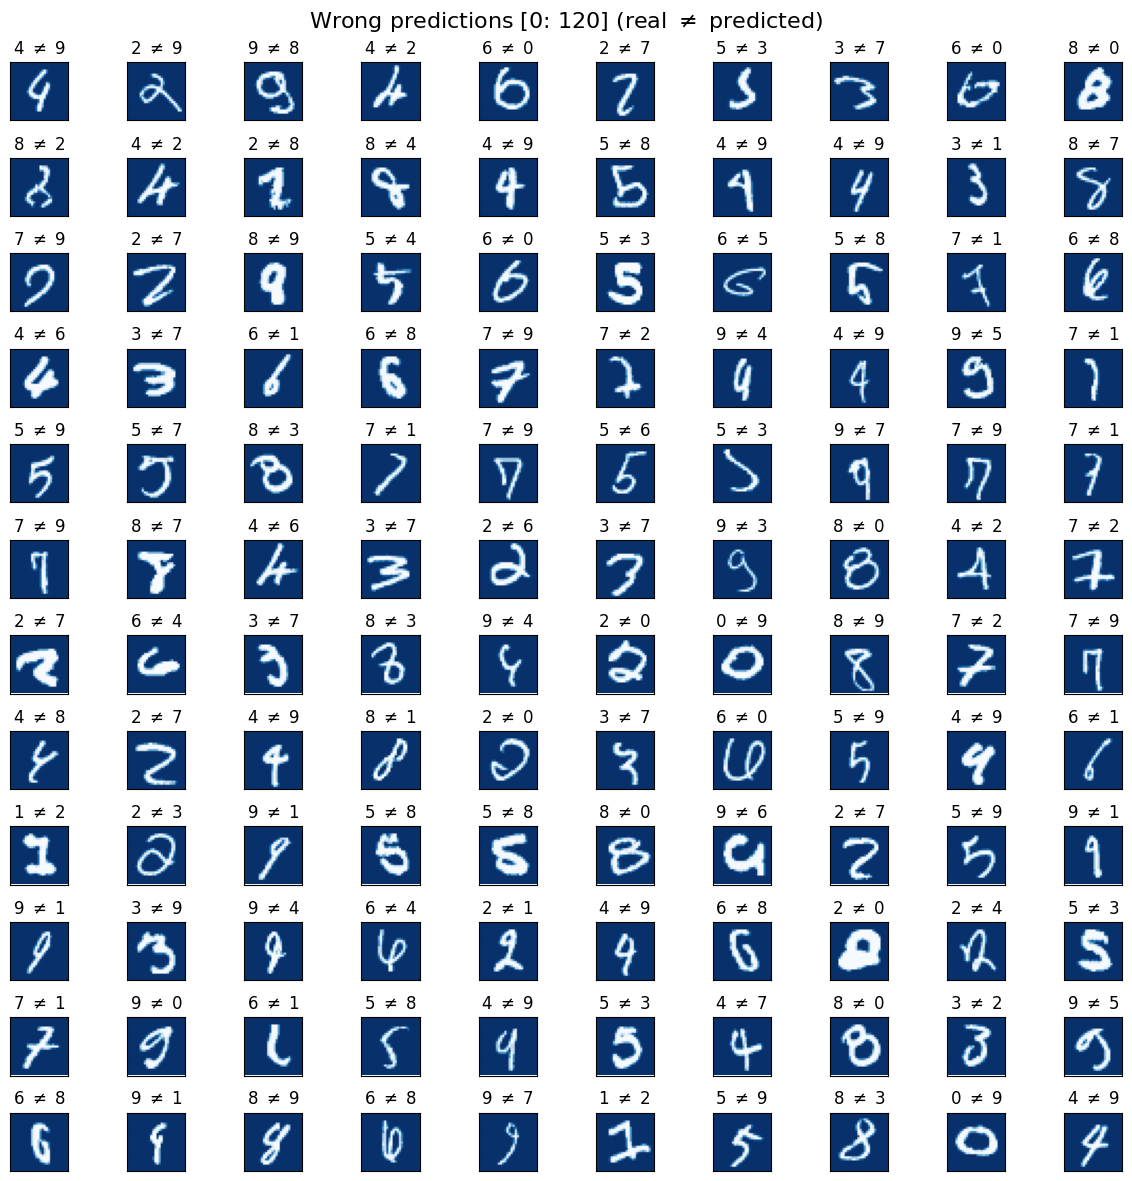

In [26]:
foo = utils.show_wrong_preds(test_images, real, pred, notequals, width, height)

Confusion matrix:

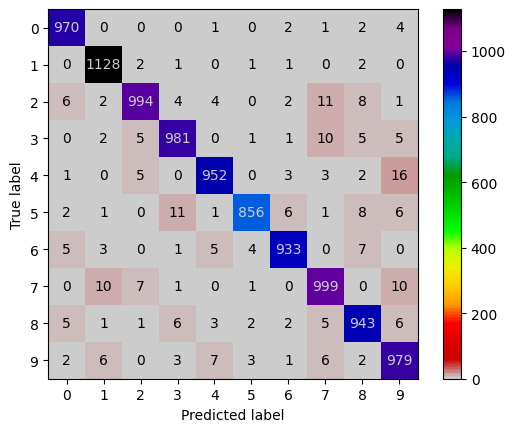

In [27]:
foo = ConfusionMatrixDisplay.from_predictions(real, pred, labels=range(10), cmap='nipy_spectral_r')

Specific mistakes:

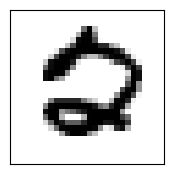

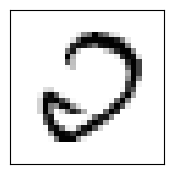

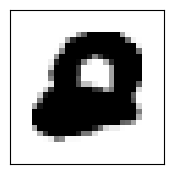

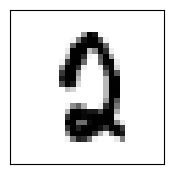

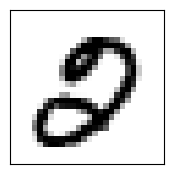

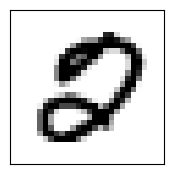

In [28]:
# 0 != 2
for i in range(len(real)):
    if pred[i] == 0 and real[i] == 2:
        digit = test_images[i]
        digit = digit.reshape(width, height)
        type(digit), digit.shape
        utils.imshow(digit)